# Laplacian Pyramid Image Coding and Reconstruction

**A multiscale study of Gaussian/Laplacian pyramids, entropy, quantization, and reconstruction quality**

This notebook explores the Laplacian pyramid as a compact image representation, following the framework introduced by Burt and Adelson. The project combines a short literature-driven theoretical foundation with a complete implementation and an experimental study of parameter sensitivity, entropy, quantization, and reconstruction quality.

**Authors:** Nikolaos Kassaris  
**Domain:** Image Processing · Multiscale Representation · Image Compression

# Research Background

The theoretical foundation of this study is based on *The Laplacian Pyramid as a Compact Image Code* by P. J. Burt and E. H. Adelson. The paper introduces a computationally efficient multiscale representation in which an image is decomposed into a Gaussian pyramid and a corresponding sequence of prediction-error images. The following sections summarize the concepts that motivate the implementation and experiments in this notebook.

## Compact Image Coding with Laplacian Pyramids

The central problem addressed by Burt and Adelson is the development of a computationally efficient image-coding technique based on prediction and multiscale transforms. Their method begins by constructing a Gaussian pyramid through repeated low-pass filtering and subsampling by a factor of $r=2$, producing an octave pyramid.

Differences between successive Gaussian-pyramid levels form decorrelated prediction errors, collectively known as the **Laplacian pyramid**. This operation is closely related to applying a Laplacian-type operator, but it is computationally cheaper. The authors propose normalized, symmetric $5\times5$ Gaussian-like kernels whose separable form makes them efficient to implement using simple shifts and additions.

The inverse process reconstructs the original image exactly when no quantization is applied. The paper also connects compression efficiency to **entropy**, interpreted as the lower bound on the average number of bits required to encode the image representation. Quantization is introduced as a mechanism for reducing entropy, with coarser quantization typically applied at higher pyramid levels. Beyond compression, the same multiscale representation is relevant to image processing, transmission, and pattern-recognition tasks.

## Gaussian Prefiltering and Aliasing Suppression

An $N$-level Gaussian pyramid of an image $I$ can be defined as

\begin{equation}
  \left\{\begin{array}{rcl}
    L^0 & = & I \\
    L^{n+1} & = & \text{REDUCE}(L^n);~n\in\{0,1,\cdots,N-1\}
  \end{array}\right.
\end{equation}

where the $\text{REDUCE}(\cdot)$ operator convolves the image with a symmetric low-pass kernel such as
$w=\{\frac{1}{16}, \frac{4}{16}, \frac{6}{16}, \frac{4}{16}, \frac{1}{16}\}$ in one dimension, extended separably to two dimensions.

The Gaussian filter suppresses high-frequency image detail before subsampling. This low-pass stage is essential because direct subsampling without prior filtering would introduce **aliasing**, causing irreversible mixing of high- and low-frequency content. By removing high-frequency components before decimation, successive pyramid levels preserve the lower-frequency structure that can be represented at the reduced sampling rate. As the spatial resolution is reduced by a factor of two per dimension, the total signal energy is also reduced substantially at successive levels.

## Why the Laplacian Representation is Effective for Compression

The Laplacian pyramid is a sequence of prediction-error images $L_0,L_1,\ldots,L_N$, where each level is formed from the difference between one Gaussian-pyramid level and an expanded version of the next coarser level. The final level corresponds to the coarsest Gaussian representation.

This representation is particularly useful for compact image coding because:

- The Laplacian coefficients are substantially less correlated than the pixels of the original image, which makes them more suitable for low-bit-rate encoding.
- The coarsest Gaussian level can be represented at a much lower spatial sampling rate because repeated low-pass filtering has removed fine detail.
- The pyramid construction provides an efficient approximation to a Laplacian-of-Gaussian decomposition without requiring a direct LoG convolution at full resolution.

As a result, the coding problem is transformed from representing the original image directly to representing a hierarchy of localized prediction errors and one coarse residual image.

## Exact Reconstruction from the Laplacian Pyramid

The original image can be reconstructed exactly, in the absence of quantization, by recursively expanding the coarsest level and adding the stored Laplacian residuals.

Conceptually, the reconstruction can be expressed as

$$I_0=\sum_{i=0}^N L_i$$

when all levels are interpreted at the original spatial resolution.

A more efficient implementation performs the process recursively: the top-level residual is expanded once and added to the next finer Laplacian level; the resulting image is then expanded again and added to the next level, continuing until the original resolution is reached. This sequence reverses the Gaussian-pyramid construction and yields exact reconstruction when the pyramid coefficients have not been altered.

# Methodology and Implementation

## Core Multiscale Operators

The implementation is organized around the generating kernel, Gaussian reduction and expansion operators, Gaussian-pyramid construction, Laplacian-pyramid construction, and inverse Laplacian reconstruction. The code cells below implement these components directly and are left unchanged from the computational workflow.

In [ ]:
# Import necessary libraries
import urllib.request
import cv2
import numpy as np
from matplotlib import rcParams, pyplot as plt
from skimage import color, data
from scipy import ndimage as ndi
%matplotlib inline

In [ ]:
# Function that generates 2D kernel
def Gkernel(a):
    b = 0.25
    c = 0.25 - a/2
    kernel1D = np.array([[c], [b], [a], [b], [c]])
    h = kernel1D @ kernel1D.T
    return h

In [ ]:
# Function that convolves input image I with kernel (Gaussian blurring) and undersamples the result by discarding odd rows and lines
def GREDUCE(I, h):
    filtered = cv2.filter2D(I, -1, h)
    I_out = cv2.resize(filtered, (filtered.shape[1]//2, filtered.shape[0]//2), interpolation=cv2.INTER_CUBIC)
    return I_out

## Gaussian Pyramid Construction

The function **`GPyramid`** constructs an $N$-level Gaussian pyramid for an image $I$:

\begin{equation}
  \left\{\begin{array}{rcl}
    G^0 & = & I \\
    G^{n+1} & = & \text{REDUCE}(G^n);~n\in\{0,1,\cdots,N-1\}
  \end{array}\right.
\end{equation}

Repeated low-pass filtering and subsampling progressively remove fine spatial detail while reducing image resolution.

In [ ]:
def GPyramid(I, a, depth):
    G = [I] # g^0 = I (initial image), base of the pyramid
    temp = I
    for i in range(depth-1):
        temp = GREDUCE(temp, Gkernel(a))
        G.append(temp)
    return G

In [ ]:
# Function that oversamples input image I and convolves the result to the 2D symmetric kernel
def GEXPAND(I, h):
    resized = cv2.resize(I, (I.shape[1]*2, I.shape[0]*2), interpolation=cv2.INTER_CUBIC)
    I_out = cv2.filter2D(resized, -1, h)
    return I_out

## Laplacian Pyramid Construction

The function **`L_Pyramid`** combines the Gaussian pyramid with the `EXPAND` operator to form a Laplacian pyramid:

\begin{equation}
  \left\{\begin{array}{rcl}
    L^{N-1} & = & G^{N-1} \text{ /* top level of the Gaussian pyramid */}\\
    L^n     & = & G^n - \text{EXPAND}(G^{n+1});~n\in\{N-2,N-3,\cdots,0\}
  \end{array}\right.
\end{equation}

Each level therefore stores the detail that is lost when moving from one Gaussian scale to the next.

In [ ]:
def L_Pyramid(I, a, depth):
    h = Gkernel(a)
    G = GPyramid(I, a, depth)
    L = [G[depth-1]]
    for n in range(depth-1):
        interpolation = GEXPAND(G[depth-n-1], h)
        difference = G[depth-n-2] - interpolation + 128
        L.append(difference)
    L.reverse()
    return L

## Inverse Reconstruction

The inverse pipeline reconstructs the original image from a Laplacian pyramid by recursively expanding the coarser representation and adding the stored detail coefficients. This provides the reconstruction mechanism used throughout the experiments below.

In [ ]:
def L_Pyramid_Decode(L,a):
    h = Gkernel(a)
    I_out = L[len(L)-1]
    for n in range(len(L)-1):
        I_out = GEXPAND(I_out, h)
        I_out = I_out + L[len(L)-n-2] - 128
    return I_out

In [ ]:
def quantize(image, bins):
  quanta = np.linspace(0, 255, num = bins) # create bins for 256 pixel values
  rolled_quanta = np.roll(quanta, -1)
  rolled_quanta[-1] = 255 # so that final bin value is 2*255
  output = (np.digitize(image, quanta) + np.digitize(image, rolled_quanta))//2 # each pixel gets the value of the middle of its containing bin
  return output.astype(np.uint8)

def L_Quantization(I, a, depth, bins):
    h = Gkernel(a)
    G = GPyramid(I, a, depth)
    L = [quantize(G[depth-1], bins[depth-1])]
    for n in range(depth-1):
        interpolation = GEXPAND(G[depth-n-1], h)
        difference = G[depth-n-2] - interpolation + 128
        L.append(quantize(difference, bins[depth-n-2])) # quantize each level of the pyamid
    L.reverse()
    return L

# Experimental Evaluation

In [ ]:
# just to center image depiction 
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

Text(0.5, 1.0, 'Grayscale Camera Image')

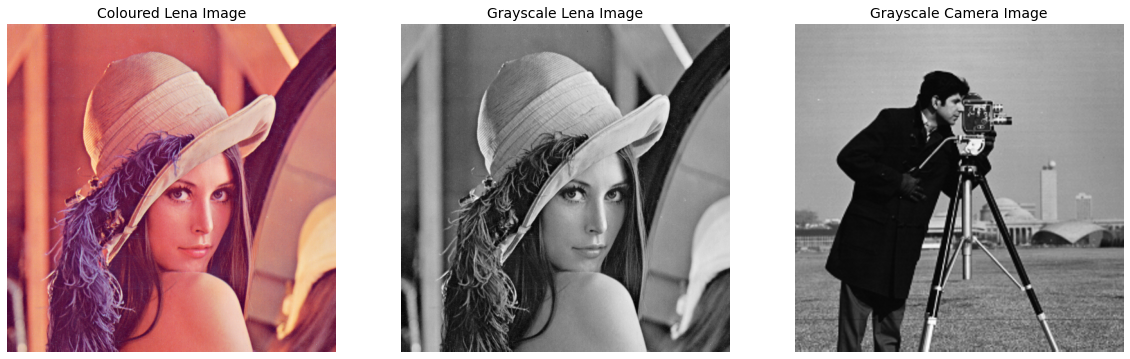

In [ ]:
# Read images Lena and Cameraman
HTTP_response = urllib.request.urlopen('http://www.image.ntua.gr/~tpar/LABimage/lena.png')
arr = np.asarray(bytearray(HTTP_response.read()), dtype=np.uint8)
BGR = cv2.imdecode(arr,-1)

lena_color = cv2.cvtColor(BGR, cv2.COLOR_BGR2RGB)
lena_gray  = cv2.cvtColor(BGR, cv2.COLOR_BGR2GRAY)
camera = data.camera()

# Show input images
rcParams['figure.figsize'] = 20,20
fig, axs = plt.subplots(1,3)
axs[0].axis('off')
axs[0].imshow(lena_color)
axs[0].set_title('Coloured Lena Image', fontsize=14)
axs[1].axis('off')
axs[1].imshow(lena_gray, cmap='gray')
axs[1].set_title('Grayscale Lena Image', fontsize=14)
axs[2].axis('off')
axs[2].imshow(camera, cmap = 'gray')
axs[2].set_title('Grayscale Camera Image', fontsize=14)

## Reconstruction Validation Across Image Types

The first experiment validates the Laplacian-pyramid encoder and decoder on three representative inputs: grayscale Lena, color Lena, and the grayscale cameraman image. This establishes whether the implementation supports both single-channel and multi-channel images while preserving the original content under lossless pyramid reconstruction.

In [ ]:
# Check functions L_Pyramid, L_Pyramid_Decode for Grayscale Lena Image

# Functions that plots all levels of Laplacian Pyramid
def plot_pyramid(image, a, depth):
  channels = len(image.shape)
  colors = {0:' RED', 1:'GREEN', 2:'BLUE'}
  if channels == 3: #colored image
    color_pyramids = []
    for i in range(channels):
      pyramid = L_Pyramid(image[:,:,i], a, depth)
      f, (ax0, ax1, ax2, ax3,ax4) = plt.subplots(1, 5, figsize=(20, 20))
      title = 'Depth of Pyramid = '+str(depth)+', Parameter a = '+str(a)+' - '+colors[i]+' CHANNEL'
      f.suptitle(title, x=0.5, y=0.6)
      ax0.imshow(pyramid[0].astype(np.uint8)) # Base of the pyramid
      ax0.set_title('L[0]', fontsize=14)
      ax0.axis('off')
      ax1.imshow(pyramid[1].astype(np.uint8))
      ax1.set_title('L[1]', fontsize=14)
      ax1.axis('off')
      ax2.imshow(pyramid[2].astype(np.uint8))
      ax2.set_title('L[2]', fontsize=14)
      ax2.axis('off')
      ax3.imshow(pyramid[3].astype(np.uint8))
      ax3.set_title('L[3]', fontsize=14)
      ax3.axis('off')
      ax4.imshow(pyramid[4].astype(np.uint8))
      ax4.set_title('L[4]', fontsize=14)
      ax4.axis('off')
      color_pyramids.append(pyramid)
    return color_pyramids
  else:
    pyramid = L_Pyramid(image, a, depth)
    f, (ax0, ax1, ax2, ax3,ax4) = plt.subplots(1, 5, figsize=(20, 20))

    title = 'Depth of Pyramid = '+str(depth)+', Parameter a = '+str(a)
    f.suptitle(title, x=0.5, y=0.6)
    ax0.imshow(pyramid[0], cmap="gray") # Base of the pyramid
    ax0.set_title('L[0]', fontsize=14)
    ax0.axis('off')
    ax1.imshow(pyramid[1], cmap="gray")
    ax1.set_title('L[1]', fontsize=14)
    ax1.axis('off')
    ax2.imshow(pyramid[2], cmap="gray")
    ax2.set_title('L[2]', fontsize=14)
    ax2.axis('off')
    ax3.imshow(pyramid[3], cmap="gray")
    ax3.set_title('L[3]', fontsize=14)
    ax3.axis('off')
    ax4.imshow(pyramid[4], cmap="gray")
    ax4.set_title('L[4]', fontsize=14)
    ax4.axis('off')
  return pyramid


# Function that checks if decoded image is a perfect copy of the original
def compare_to_original(image, pyramid, a):
  channels = len(image.shape)
  rcParams['figure.figsize'] = 6,6
  if channels == 3: # colored images
    retrieved = np.zeros(image.shape)
    for i in range(channels):
      retrieved[:,:,i] = L_Pyramid_Decode(pyramid[i],a)
    plt.imshow(retrieved.astype(np.uint8))
  else:
    retrieved = L_Pyramid_Decode(pyramid, a)
    plt.imshow(retrieved, cmap='gray')
  plt.axis('off')
  if (np.array_equal(retrieved, image)):
    print('Original Image perfectly retrieved!')
  else:
    print('Image Distorted!')
  return retrieved

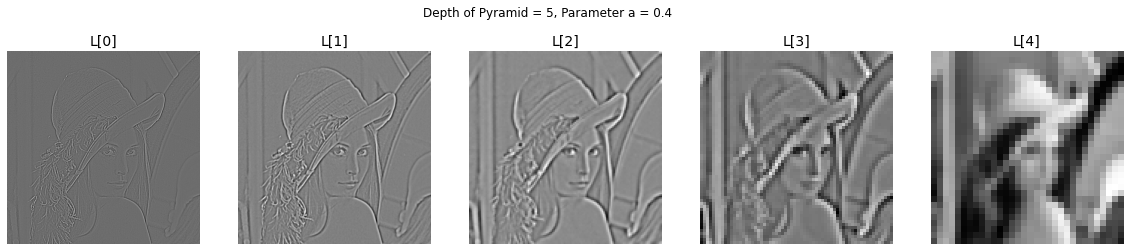

In [ ]:
lena_pyramid = plot_pyramid(lena_gray, a = 0.4, depth = 5)

Original Image perfectly retrieved!


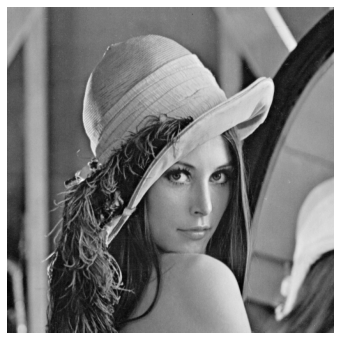

In [ ]:
lena_retrieved = compare_to_original(lena_gray, lena_pyramid, a = 0.4)

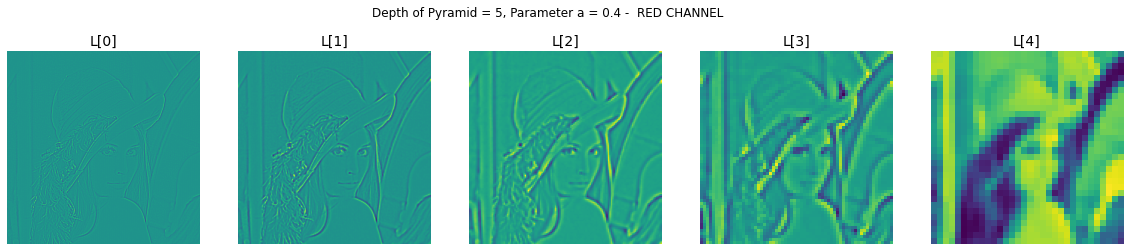

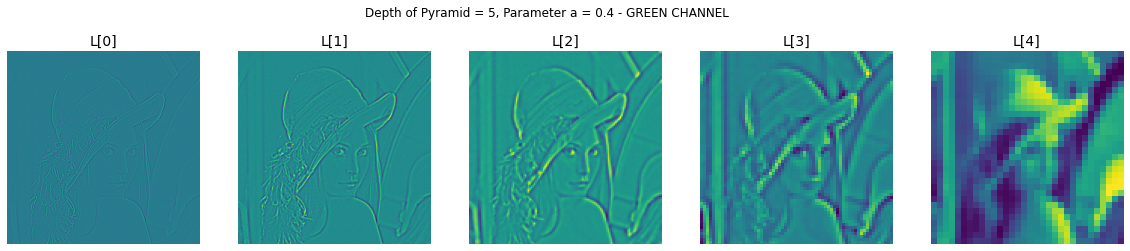

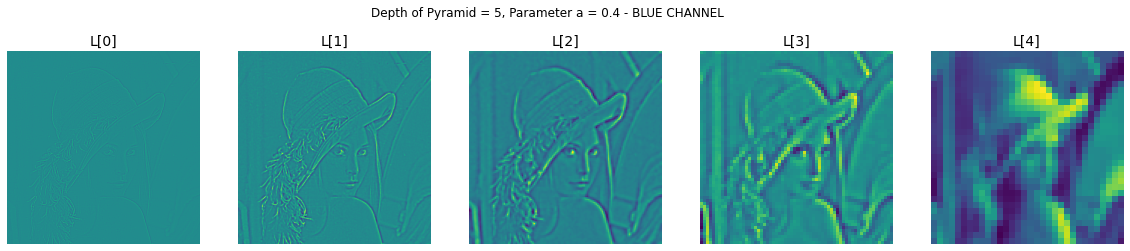

In [ ]:
color_pyramid = plot_pyramid(lena_color, a = 0.4, depth = 5)

Original Image perfectly retrieved!


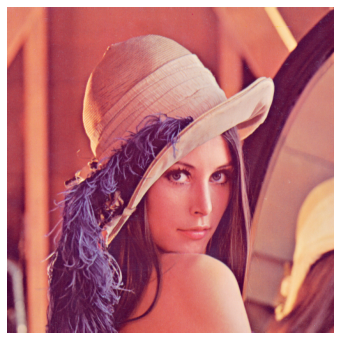

In [ ]:
color_retrieved = compare_to_original(lena_color, color_pyramid, a = 0.4)

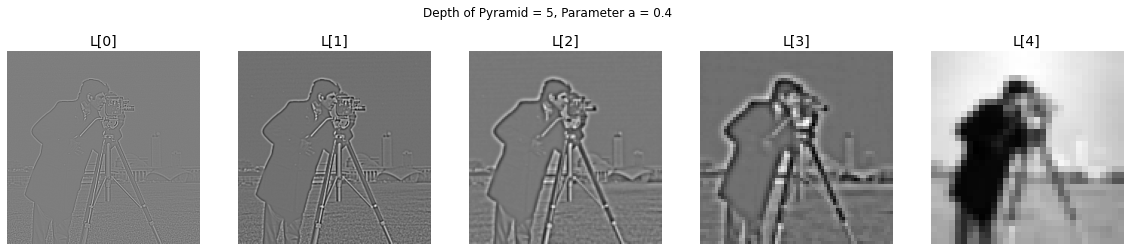

In [ ]:
camera_pyramid = plot_pyramid(camera, a = 0.4, depth = 5)

Original Image perfectly retrieved!


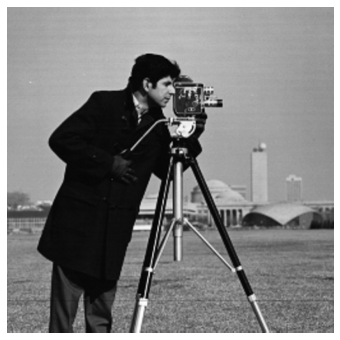

In [ ]:
camera_retrieved = compare_to_original(camera, camera_pyramid, a = 0.4)

The three test images are reconstructed successfully from their Laplacian pyramids. With $\alpha=0.4$, the generating kernel behaves as a Gaussian-like smoothing filter. The resulting Laplacian levels resemble band-pass responses related to a Laplacian-of-Gaussian representation, emphasizing spatial detail at different scales while retaining enough information for exact reconstruction.

## Sensitivity to the Generating-Kernel Parameter $\alpha$

The reconstructed images and intermediate pyramid levels are evaluated over several values of $\alpha$ in the interval $[0.2,0.7]$. The purpose is to study how the kernel shape changes the multiscale decomposition and how strongly each level preserves or suppresses image detail.

For the remainder of this parameter study, the experiments focus primarily on the grayscale Lena and cameraman images for clarity.

In [ ]:
a_vector = [0.2, 0.3, 0.5, 0.6, 0.7]
depth_vector = [2, 4, 5, 6, 7]

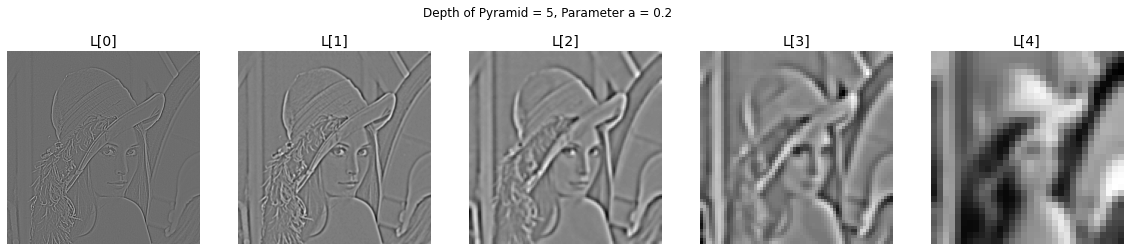

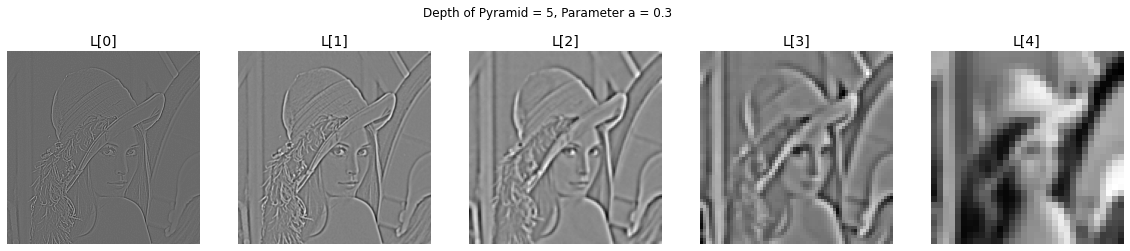

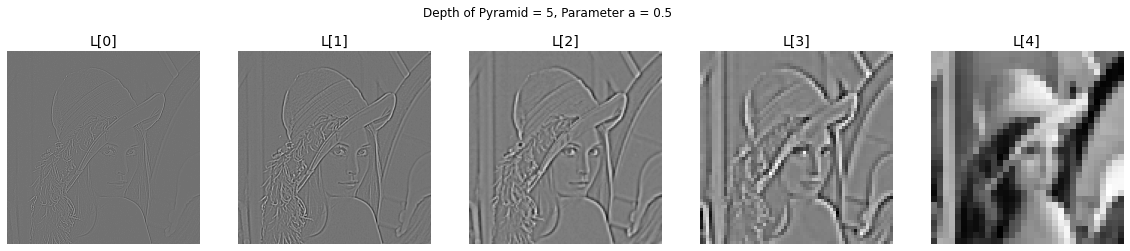

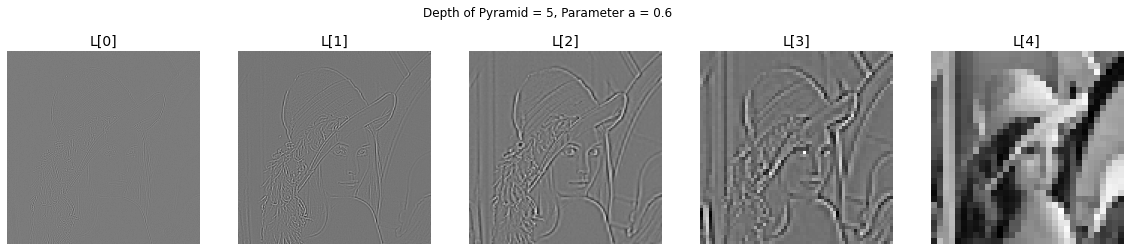

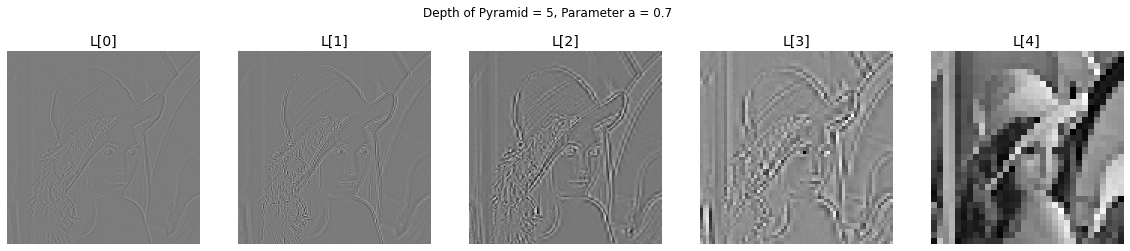

In [ ]:
for a in a_vector:
  lena_pyramid = plot_pyramid(lena_gray, a, depth = 5)

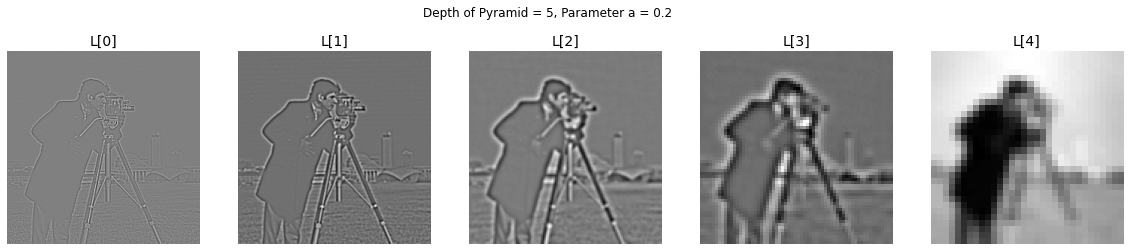

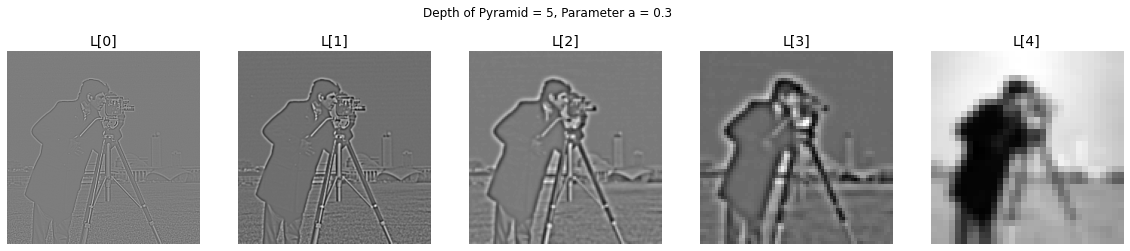

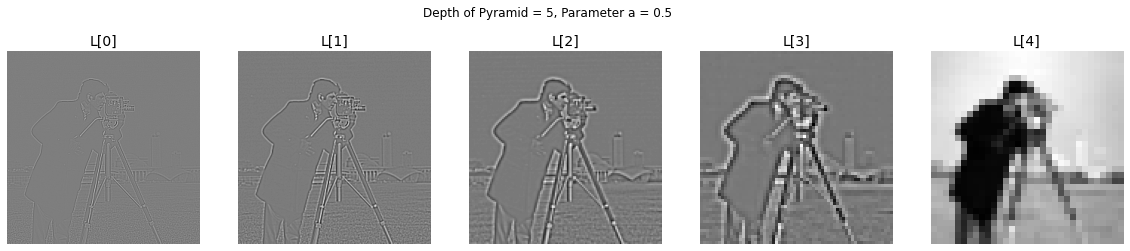

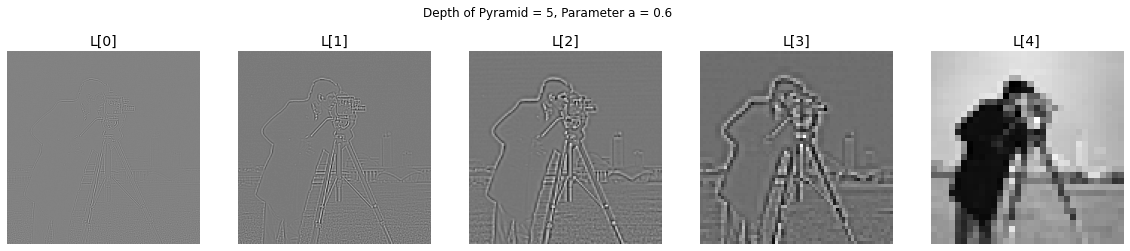

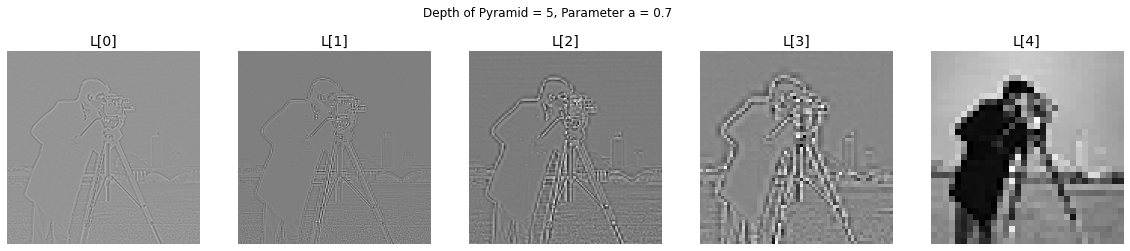

In [ ]:
for a in a_vector:
  camera_pyramid = plot_pyramid(camera, a, depth = 5)

Increasing $\alpha$ produces stronger smoothing in the Laplacian-pyramid levels, making fine image details progressively less distinct. This behavior follows directly from the dependence of the generating kernel on $\alpha$: for example, the kernel is trimodal around $\alpha=0.6$, triangular around $\alpha=0.5$, and approximately Gaussian around $\alpha=0.4$.

At larger values of $\alpha$, the base Laplacian level becomes substantially more blurred, and the original image silhouette is increasingly absorbed into the gray background. The experiment therefore demonstrates that $\alpha$ controls the balance between retained spatial detail and concentration of the residual coefficients.

## Effect of Pyramid Depth on Reconstruction

The next experiment varies the Laplacian-pyramid depth over the interval $[2,7]$ while keeping $\alpha=0.4$. This isolates the effect of multiscale depth and shows how progressively coarser representations influence the decomposition and reconstructed output.

In [ ]:
# Function that plots levels of Gaussian Pyramids for different Depths
def plot_pyramid_depths(image, a, depth):
  pyramid = L_Pyramid(image, a, depth)
  size_dict = {2:6, 4:10, 5:12, 6:14, 7:20}
  f, axs = plt.subplots(1, depth, figsize=(size_dict[depth], size_dict[depth]))
  
  for i in range(depth):
    minititle = 'L['+str(i)+']'
    axs[i].imshow(pyramid[i], cmap="gray") # Base of the pyramid
    axs[i].set_title(minititle, fontsize=14)
    axs[i].axis('off')
  return pyramid

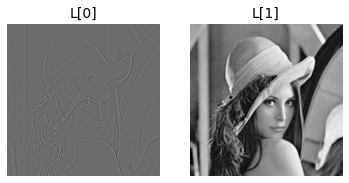

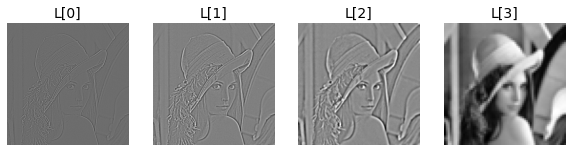

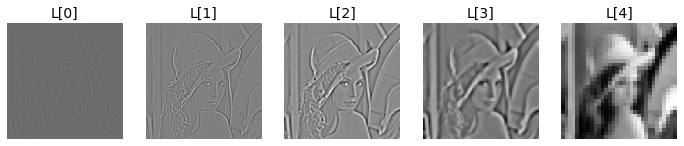

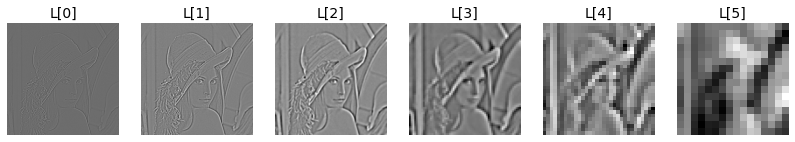

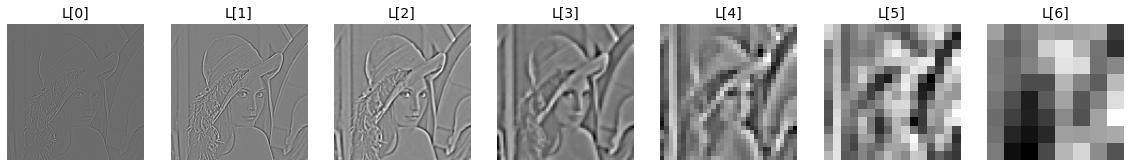

In [ ]:
for depth in depth_vector:
  lena_pyramid = plot_pyramid_depths(lena_gray, 0.4, depth)

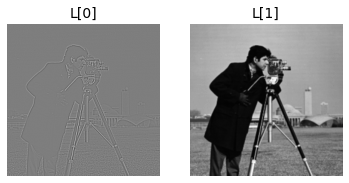

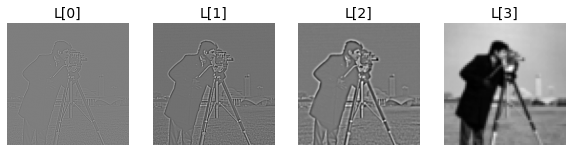

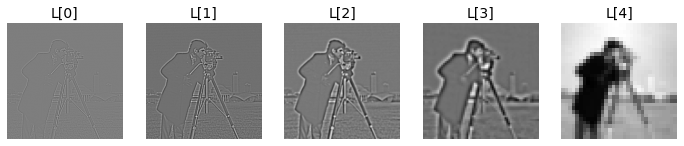

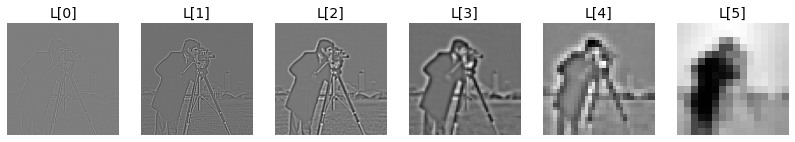

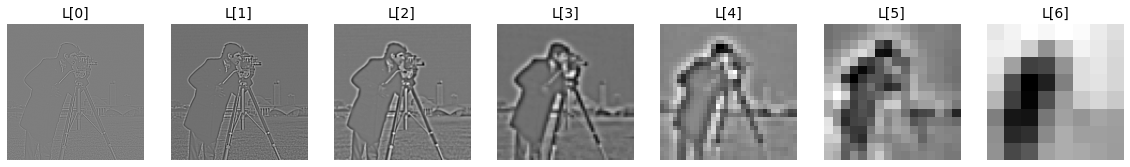

In [ ]:
for depth in depth_vector:
  camera_pyramid = plot_pyramid_depths(camera, 0.4, depth)

## Entropy Across Kernel Parameters and Pyramid Depth

Entropy is used as a quantitative proxy for coding efficiency. The following experiments measure the entropy of the pyramid representations for different values of $\alpha$ and `depth`, together with the corresponding coefficient-distribution histograms.

In [ ]:
# Function that calculates the Histogram of a Laplacian Pyramid of depth N
def histogram(pyramid, N):
  sum_hist = np.zeros([256,1], np.float64)
  for n in range(N):
      hist = cv2.calcHist([pyramid[n]], [0], None, [256], [0, 256])
      sum_hist += hist
  return sum_hist/sum_hist.max() # normalized histogram

import scipy.stats as st

# Function that calculates Entropy of Image given its Histogram
def entropy_calc(histogram):
  return st.entropy(histogram, base = 2)[0]

In [ ]:
# Function that plots histograms of Gaussian Pyramids for different Depths and a parameters
def plot_hist(image, a_vector, depth_vector):
  max_plots = max(len(depth_vector), len(a_vector))
  f, axs = plt.subplots(1, max_plots, figsize=(24, 7))
  count = 0
  for a in a_vector:
    for depth in depth_vector:
        channels = len(image.shape)
        if channels==3: #colored images
          hist = []
          colors = ['r','g','b']
          for i in range(channels):
            pyramid = L_Pyramid(image[:,:,i], a, depth)
            temp = histogram(pyramid, depth)
            axs[count].plot(temp, colors[i])
            hist.append(temp)
          entropy = (entropy_calc(hist[0]) +  entropy_calc(hist[1]) + entropy_calc(hist[2]))/3
        else:
          pyramid = L_Pyramid(image, a, depth)
          hist = histogram(pyramid, depth)
          axs[count].plot(hist)
          entropy = entropy_calc(hist)
        minititle = 'Depth = '+str(depth)+', Parameter a = '+str(a)
        axs[count].set_title(minititle, fontsize=10)
        count = count + 1
        print('Depth = ', depth,', Parameter a = ', a,': Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))
        if count == max_plots:
          print()
          return pyramid, hist, entropy
  return pyramid, hist, entropy

### Grayscale Lena

The entropy analysis begins with the grayscale Lena image, allowing the effect of the decomposition parameters to be observed without channel-level variation.

--------- Grayscale Lena Image - Entropy for Different a -----------

Depth =  5 , Parameter a =  0.2 : Entropy =  4.8557 , Variance of Histogram =  0.0153
Depth =  5 , Parameter a =  0.3 : Entropy =  4.7233 , Variance of Histogram =  0.0147
Depth =  5 , Parameter a =  0.5 : Entropy =  4.343 , Variance of Histogram =  0.0133
Depth =  5 , Parameter a =  0.6 : Entropy =  4.177 , Variance of Histogram =  0.0136
Depth =  5 , Parameter a =  0.7 : Entropy =  4.2843 , Variance of Histogram =  0.0147



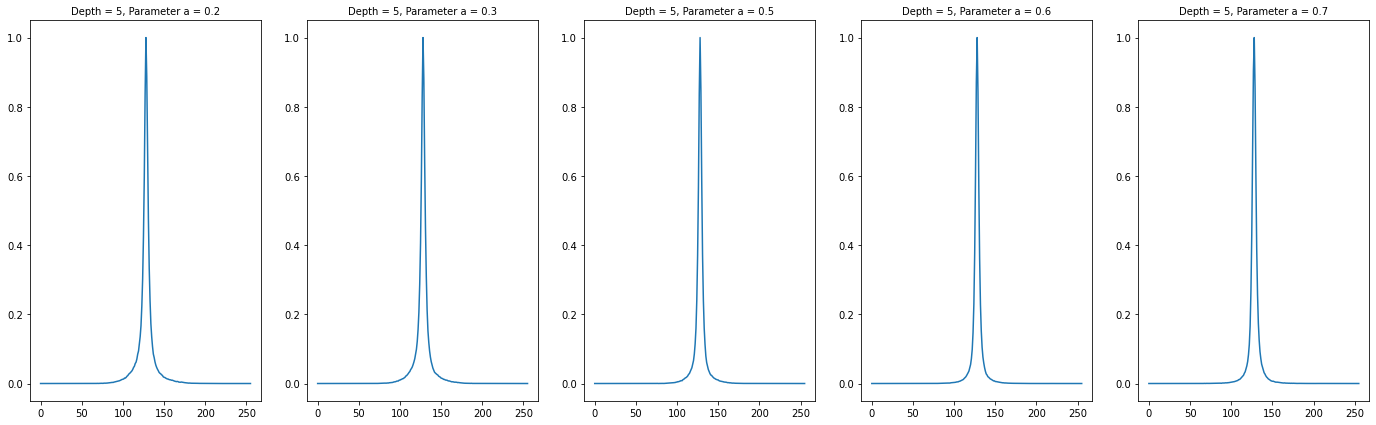

In [ ]:
print('--------- Grayscale Lena Image - Entropy for Different a -----------')
print()
lena_pyr, lena_hist, entropy = plot_hist(lena_gray, a_vector, depth_vector = [5])

--------- Grayscale Lena Image - Entropy for Different Depths -----------

Depth =  2 , Parameter a =  0.4 : Entropy =  5.4403 , Variance of Histogram =  0.0163
Depth =  4 , Parameter a =  0.4 : Entropy =  4.5878 , Variance of Histogram =  0.0142
Depth =  5 , Parameter a =  0.4 : Entropy =  4.553 , Variance of Histogram =  0.0142
Depth =  6 , Parameter a =  0.4 : Entropy =  4.5467 , Variance of Histogram =  0.0142
Depth =  7 , Parameter a =  0.4 : Entropy =  4.5458 , Variance of Histogram =  0.0142



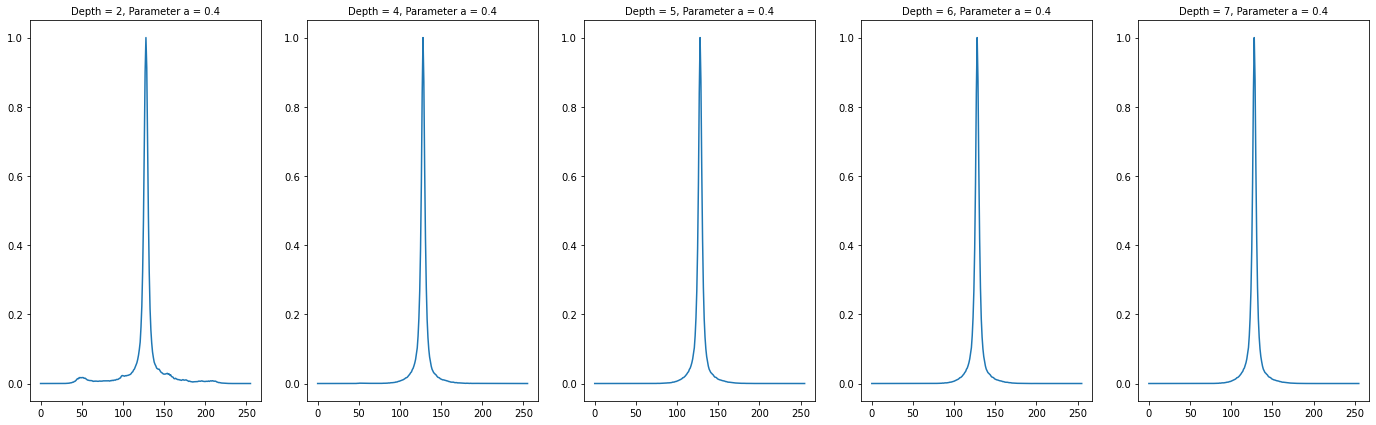

In [ ]:
print('--------- Grayscale Lena Image - Entropy for Different Depths -----------')
print()
lena_pyr, lena_hist, entropy = plot_hist(lena_gray, [0.4], depth_vector)

### Color Lena

The same entropy analysis is repeated for the color Lena image to examine how multichannel image content influences the coefficient distributions and coding characteristics.

--------- Colored Lena Image - Entropy for Different a -----------

Depth =  5 , Parameter a =  0.2 : Entropy =  4.9353 , Variance of Histogram =  0.0184
Depth =  5 , Parameter a =  0.3 : Entropy =  4.8213 , Variance of Histogram =  0.0176
Depth =  5 , Parameter a =  0.5 : Entropy =  4.4996 , Variance of Histogram =  0.0169
Depth =  5 , Parameter a =  0.6 : Entropy =  4.3601 , Variance of Histogram =  0.0174
Depth =  5 , Parameter a =  0.7 : Entropy =  4.4507 , Variance of Histogram =  0.0191



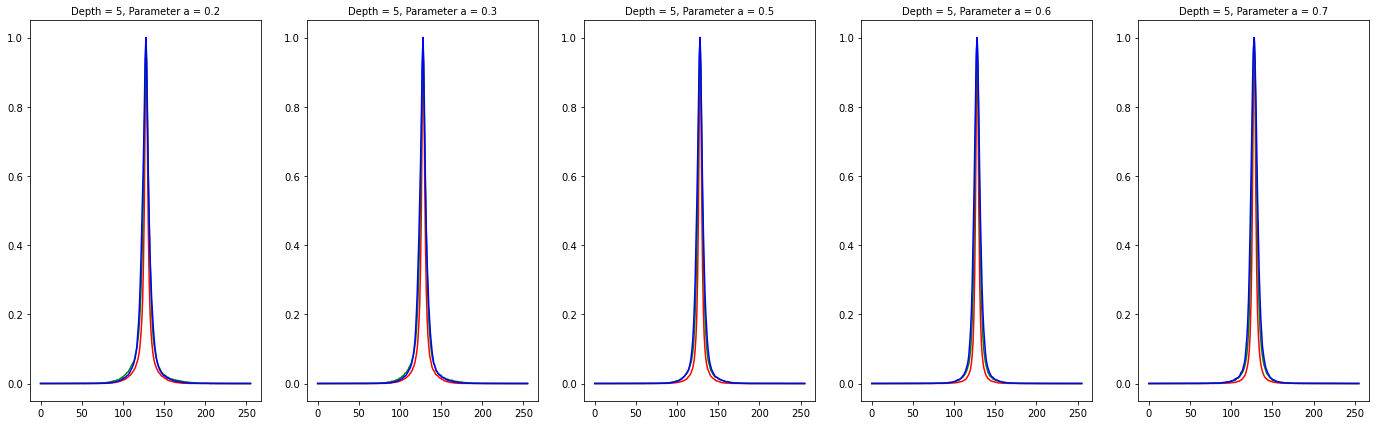

In [ ]:
print('--------- Colored Lena Image - Entropy for Different a -----------')
print()
color_pyr, color_hist, entropy = plot_hist(lena_color, a_vector, depth_vector = [5])

--------- Colored Lena Image - Entropy for Different Depths -----------

Depth =  2 , Parameter a =  0.4 : Entropy =  5.5973 , Variance of Histogram =  0.0216
Depth =  4 , Parameter a =  0.4 : Entropy =  4.7191 , Variance of Histogram =  0.0171
Depth =  5 , Parameter a =  0.4 : Entropy =  4.6754 , Variance of Histogram =  0.0171
Depth =  6 , Parameter a =  0.4 : Entropy =  4.666 , Variance of Histogram =  0.0171
Depth =  7 , Parameter a =  0.4 : Entropy =  4.6638 , Variance of Histogram =  0.0171



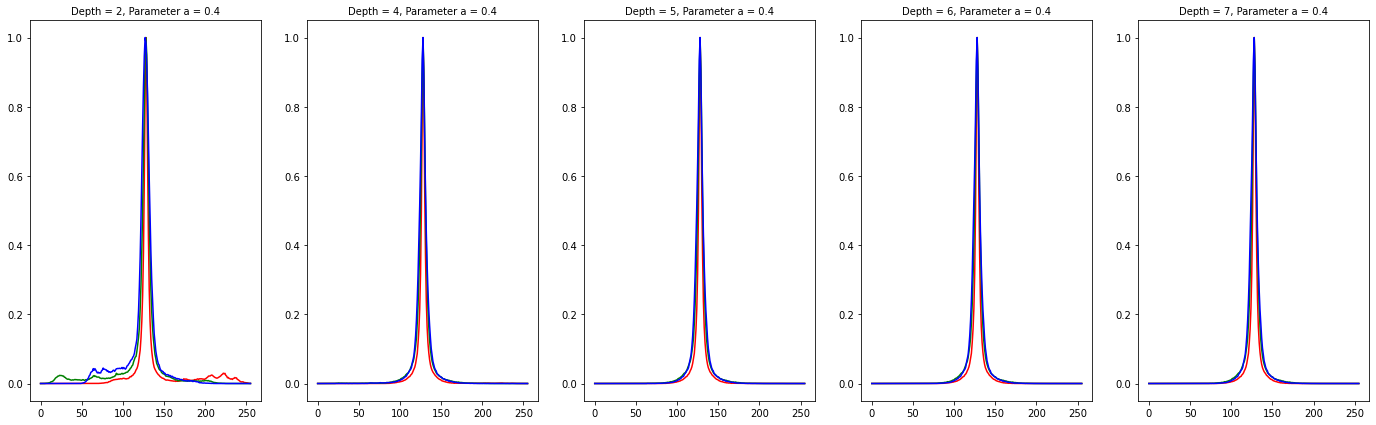

In [ ]:
print('--------- Colored Lena Image - Entropy for Different Depths -----------')
print()
color_pyr, color_hist, entropy = plot_hist(lena_color, [0.4], depth_vector)

### Grayscale Cameraman

The final entropy sweep is performed on the grayscale cameraman image, providing a second grayscale image with different edge and texture characteristics.

--------- Grayscale Camera Image - Entropy for Different a -----------

Depth =  5 , Parameter a =  0.2 : Entropy =  4.5197 , Variance of Histogram =  0.0083
Depth =  5 , Parameter a =  0.3 : Entropy =  4.3612 , Variance of Histogram =  0.0079
Depth =  5 , Parameter a =  0.5 : Entropy =  3.8643 , Variance of Histogram =  0.0066
Depth =  5 , Parameter a =  0.6 : Entropy =  3.554 , Variance of Histogram =  0.0061
Depth =  5 , Parameter a =  0.7 : Entropy =  3.7119 , Variance of Histogram =  0.0063



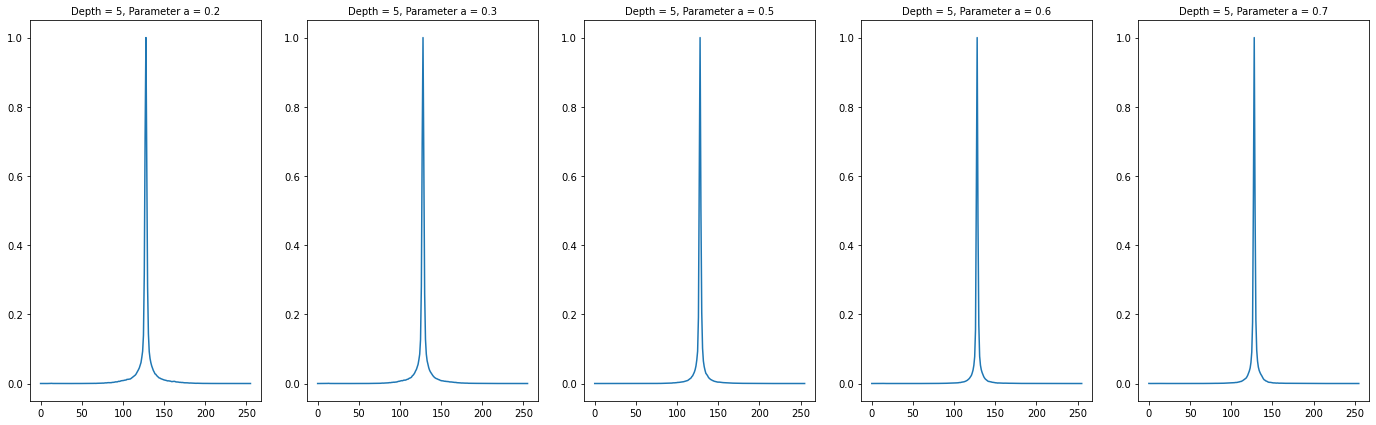

In [ ]:
print('--------- Grayscale Camera Image - Entropy for Different a -----------')
print()
camera_pyr, camera_hist, entropy = plot_hist(camera, a_vector, depth_vector = [5])

--------- Grayscale Camera Image - Entropy for Different Depths -----------

Depth =  2 , Parameter a =  0.4 : Entropy =  5.0298 , Variance of Histogram =  0.0073
Depth =  4 , Parameter a =  0.4 : Entropy =  4.1924 , Variance of Histogram =  0.0073
Depth =  5 , Parameter a =  0.4 : Entropy =  4.1487 , Variance of Histogram =  0.0073
Depth =  6 , Parameter a =  0.4 : Entropy =  4.1391 , Variance of Histogram =  0.0073
Depth =  7 , Parameter a =  0.4 : Entropy =  4.1374 , Variance of Histogram =  0.0073



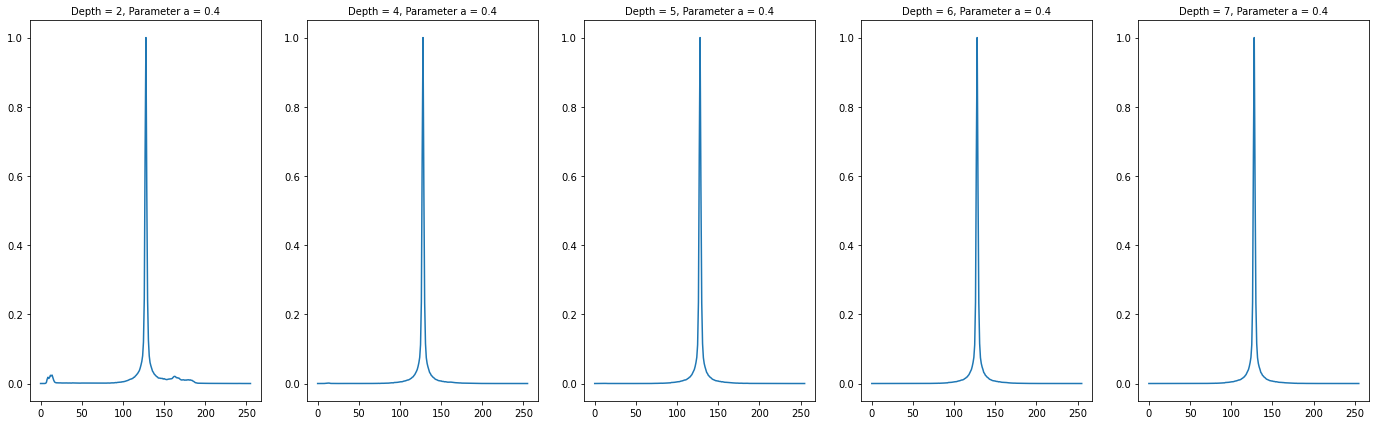

In [ ]:
print('--------- Grayscale Camera Image - Entropy for Different Depths -----------')
print()
camera_pyr, camera_hist, entropy = plot_hist(camera, [0.4], depth_vector)

Across the experiments, increasing $\alpha$ generally reduces image entropy and produces a narrower coefficient histogram, indicating that the representation becomes more concentrated and potentially requires fewer bits to encode. The lowest entropy is observed near $\alpha=0.6$ for both image families.

By contrast, increasing the number of pyramid levels tends to increase the measured entropy and broaden the value distribution. This suggests a practical trade-off: low-entropy representations are favored by relatively large values of $\alpha$ and modest pyramid depth, while deeper decompositions provide a richer multiscale representation.

## Entropy-Driven Selection of $\alpha$

After exploring both kernel shape and pyramid depth, the parameter study is refined to identify the value of $\alpha$ that minimizes entropy at each Laplacian-pyramid level. The pyramid depth is fixed at **`depth = 5`** so that the effect of $\alpha$ can be compared consistently across images and scales.

In [ ]:
# Function that prints Entropy and Variance for each Level of Laplacian Pyramid
def print_per_level(image, a,  N):
  pyramid = L_Pyramid(image, a, N)
  for n in range(N):
      hist = cv2.calcHist([pyramid[n]], [0], None, [256], [0, 256])
      print('Depth Level = ', n+1,': Entropy = ', entropy_calc(hist), ', Variance = ', np.var(hist))

def print_per_a(image, a_vector, depth):
  for a in a_vector:
    print('Parameter a = ', a)
    print_per_level(image, a, depth)
    print()


In [ ]:
print('--------------- Grayscale Lena Image --------------- \n')
print_per_a(lena_gray, a_vector, 5)
print('--------------- Colour Lena Image ---------------\n')
print_per_a(lena_color, a_vector, 5)
print('--------------- Grayscale Camera Image ---------------\n')
print_per_a(camera, a_vector, 5)

--------------- Grayscale Lena Image --------------- 

Parameter a =  0.2
Depth Level =  1 : Entropy =  4.7748456 , Variance =  14946503.0
Depth Level =  2 : Entropy =  4.79679 , Variance =  1053100.4
Depth Level =  3 : Entropy =  5.3959146 , Variance =  36144.156
Depth Level =  4 : Entropy =  5.9075956 , Variance =  1137.8281
Depth Level =  5 : Entropy =  6.979996 , Variance =  21.3125

Parameter a =  0.3
Depth Level =  1 : Entropy =  4.638189 , Variance =  16261402.0
Depth Level =  2 : Entropy =  4.6708107 , Variance =  1164667.8
Depth Level =  3 : Entropy =  5.2575674 , Variance =  42235.72
Depth Level =  4 : Entropy =  5.824477 , Variance =  1274.4922
Depth Level =  5 : Entropy =  7.0085936 , Variance =  20.921875

Parameter a =  0.5
Depth Level =  1 : Entropy =  4.228498 , Variance =  20756684.0
Depth Level =  2 : Entropy =  4.349 , Variance =  1455895.6
Depth Level =  3 : Entropy =  4.941927 , Variance =  57393.664
Depth Level =  4 : Entropy =  5.5772314 , Variance =  1865.5781
D

Across most pyramid levels, the minimum entropy is achieved at approximately $\alpha=0.6$, with only a small number of cases favoring $\alpha=0.5$. This makes **$\alpha\approx0.6$** the strongest overall choice for the tested Lena and cameraman images under the selected depth.

The values below summarize the lowest observed entropy and the corresponding histogram variance for the three image cases.

- **Grayscale Lena:** Lowest Entropy = 4.177, Variance of Histogram = 0.0136  
- **Color Lena:** Lowest Entropy = 4.3601, Variance of Histogram = 0.0174  
- **Grayscale Cameraman:** Lowest Entropy = 3.554, Variance of Histogram = 0.0061

## Quantization at the Selected Kernel Setting

Using the empirically selected value $\alpha=0.6$, the Laplacian coefficients are quantized with different bin sizes. The objective is to study the compression–distortion trade-off: coarser quantization reduces the number of distinct coefficient values and therefore the entropy, but it also introduces reconstruction error.

In [ ]:
# Functions that plots all levels of Laplacian Pyramid
def plot_quantized_pyramid(image, a, depth, bins):
  channels = len(image.shape)
  colors = {0:' RED', 1:'GREEN', 2:'BLUE'}
  if channels == 3: #colored image
    color_pyramids = []
    for i in range(channels):
      pyramid = L_Quantization(image[:,:,i], a, depth, bins)
      f, (ax0, ax1, ax2, ax3,ax4) = plt.subplots(1, 5, figsize=(20, 20))
      title = 'Depth of Pyramid = '+str(depth)+', Parameter a = '+str(a)+' - '+colors[i]+' CHANNEL'
      f.suptitle(title, x=0.5, y=0.6)
      ax0.imshow(pyramid[0].astype(np.uint8)) # Base of the pyramid
      ax0.set_title('L[0]', fontsize=14)
      ax0.axis('off')
      ax1.imshow(pyramid[1].astype(np.uint8))
      ax1.set_title('L[1]', fontsize=14)
      ax1.axis('off')
      ax2.imshow(pyramid[2].astype(np.uint8))
      ax2.set_title('L[2]', fontsize=14)
      ax2.axis('off')
      ax3.imshow(pyramid[3].astype(np.uint8))
      ax3.set_title('L[3]', fontsize=14)
      ax3.axis('off')
      ax4.imshow(pyramid[4].astype(np.uint8))
      ax4.set_title('L[4]', fontsize=14)
      ax4.axis('off')
      color_pyramids.append(pyramid)
    return color_pyramids
  else:
    pyramid = L_Quantization(image, a, depth, bins)
    f, (ax0, ax1, ax2, ax3,ax4) = plt.subplots(1, 5, figsize=(20, 20))

    title = 'Depth of Pyramid = '+str(depth)+', Parameter a = '+str(a) +', No of Bins = '+str(bins)
    f.suptitle(title, x=0.5, y=0.6)
    ax0.imshow(pyramid[0], cmap="gray") # Base of the pyramid
    ax0.set_title('L[0]', fontsize=14)
    ax0.axis('off')
    ax1.imshow(pyramid[1], cmap="gray")
    ax1.set_title('L[1]', fontsize=14)
    ax1.axis('off')
    ax2.imshow(pyramid[2], cmap="gray")
    ax2.set_title('L[2]', fontsize=14)
    ax2.axis('off')
    ax3.imshow(pyramid[3], cmap="gray")
    ax3.set_title('L[3]', fontsize=14)
    ax3.axis('off')
    ax4.imshow(pyramid[4], cmap="gray")
    ax4.set_title('L[4]', fontsize=14)
    ax4.axis('off')
    return pyramid

### Quantization of Grayscale Lena

The Laplacian-pyramid levels of the grayscale Lena image are quantized using multiple bin configurations to evaluate the resulting changes in entropy and visual reconstruction quality.

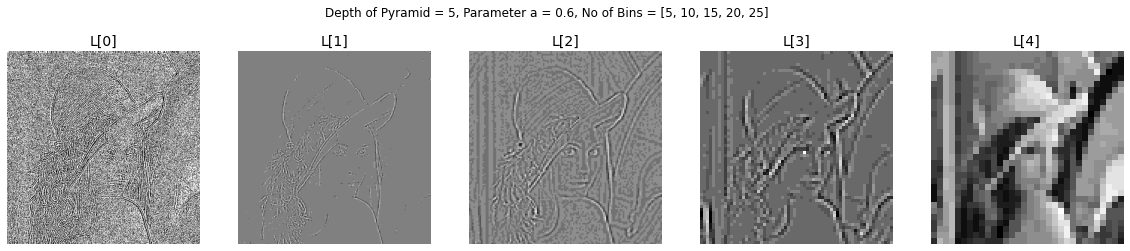

In [ ]:
lena_experiments = []
bins1 = [5, 10, 15, 20, 25]
quant_lena_pyr1 = plot_quantized_pyramid(image = lena_gray, a = 0.6, depth = 5, bins = bins1)

Image Distorted!
Quantizing with 5 bins:  Entropy =  1.9659 , Variance of Histogram =  0.0067


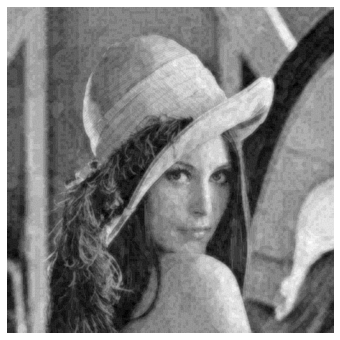

In [ ]:
retrieved_lena1 = compare_to_original(lena_gray, quant_lena_pyr1, a = 0.6)
lena_experiments.append(retrieved_lena1)

hist = histogram(quant_lena_pyr1, 5)
entropy = entropy_calc(hist)
print('Quantizing with 5 bins:',' Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))

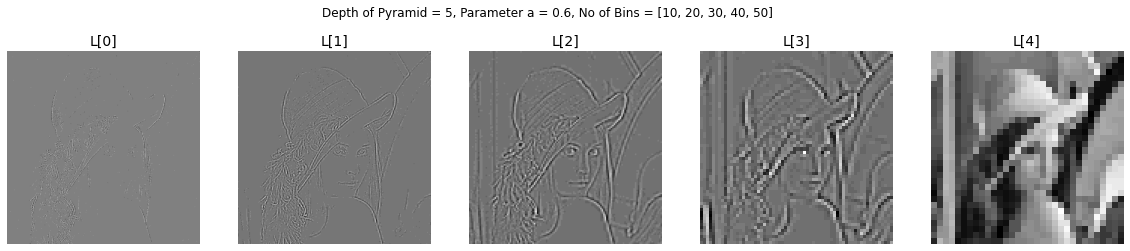

In [ ]:
bins2 = [10, 20, 30, 40, 50]
quant_lena_pyr2 = plot_quantized_pyramid(image = lena_gray, a = 0.6, depth = 5, bins = bins2)

Image Distorted!
Quantizing with 25 bins:  Entropy =  1.5151 , Variance of Histogram =  0.0041


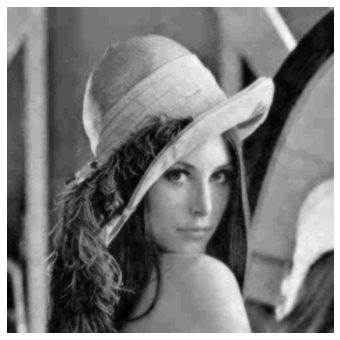

In [ ]:
retrieved_lena2 = compare_to_original(lena_gray, quant_lena_pyr2, a = 0.6)
lena_experiments.append(retrieved_lena2)

hist = histogram(quant_lena_pyr2, 5)
entropy = entropy_calc(hist)
print('Quantizing with 25 bins:',' Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))

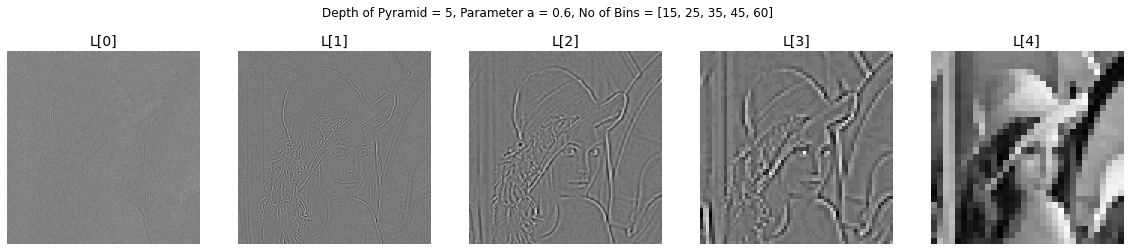

In [ ]:
bins3 = [15, 25, 35, 45, 60]
quant_lena_pyr3 = plot_quantized_pyramid(image = lena_gray, a = 0.6, depth = 5, bins = bins3)

Image Distorted!
Quantizing with 50 bins:  Entropy =  2.2935 , Variance of Histogram =  0.0064


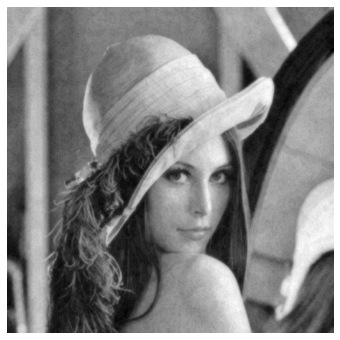

In [ ]:
retrieved_lena3 = compare_to_original(lena_gray, quant_lena_pyr3, a = 0.6)
lena_experiments.append(retrieved_lena3)

hist = histogram(quant_lena_pyr3, 5)
entropy = entropy_calc(hist)
print('Quantizing with 50 bins:',' Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))

### Quantization of Color Lena

The quantization experiment is repeated for the color Lena image to assess whether the same binning strategy affects multichannel reconstruction differently.

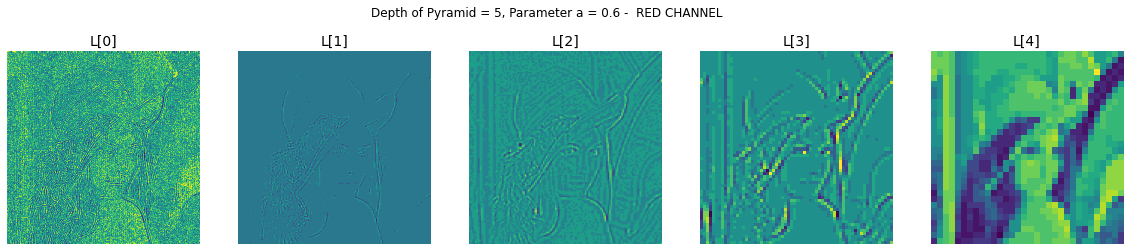

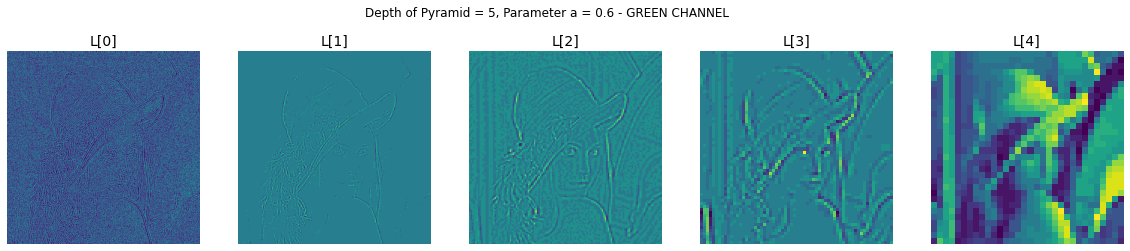

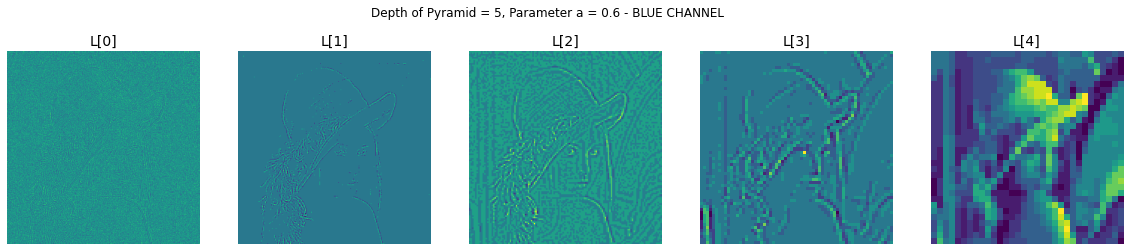

In [ ]:
quant_color_pyr1 = plot_quantized_pyramid(image = lena_color, a = 0.6, depth = 5, bins = bins1)
color_experiments = []

Image Distorted!
Quantizing with 15 bins:  Entropy =  1.9655 , Variance of Histogram =  0.0071


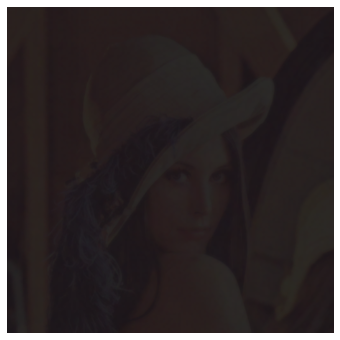

In [ ]:
retrieved_color1 = compare_to_original(lena_color, quant_color_pyr1, a = 0.6)
color_experiments.append(retrieved_color1)

hist = np.zeros([256,1], np.float64)
for pyramid in quant_color_pyr1:
  temp = histogram(pyramid, 5)
  hist = hist + temp
hist = hist / 3
entropy = entropy_calc(hist)
print('Quantizing with 15 bins:',' Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))

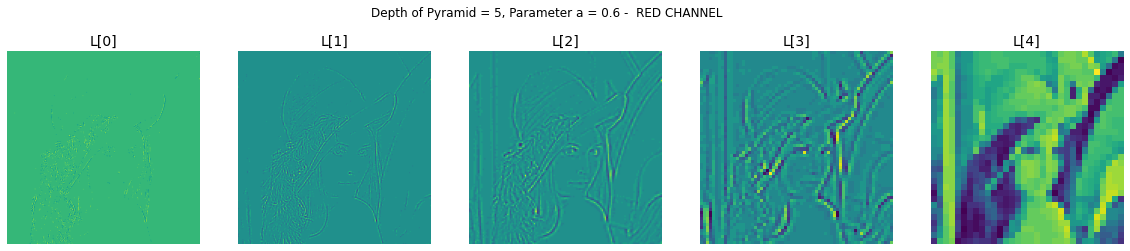

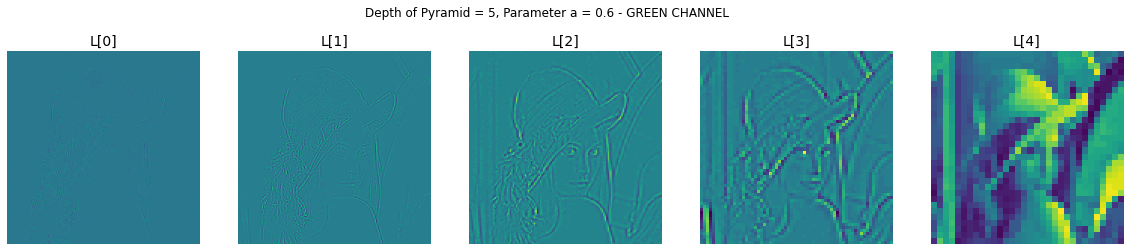

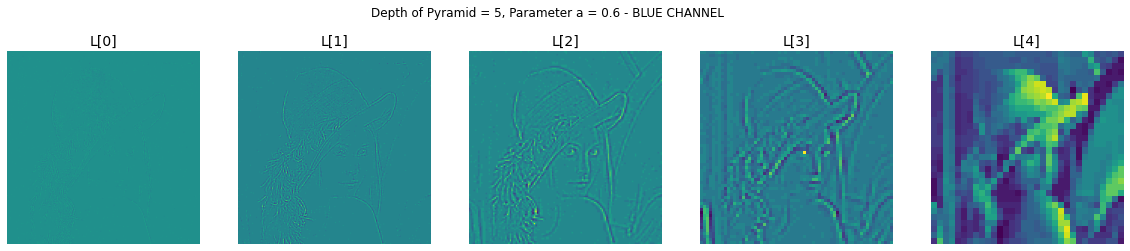

In [ ]:
quant_color_pyr2 = plot_quantized_pyramid(image = lena_color, a = 0.6, depth = 5, bins = bins2)

Image Distorted!
Quantizing with 50 bins:  Entropy =  1.5366 , Variance of Histogram =  0.0041


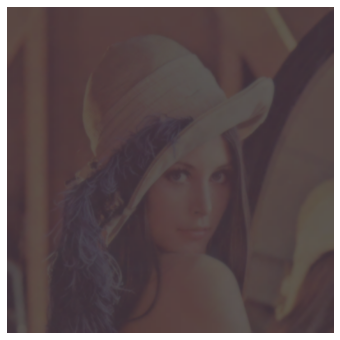

In [ ]:
retrieved_color2 = compare_to_original(lena_color, quant_color_pyr2, a = 0.6)
color_experiments.append(retrieved_color2)

hist = np.zeros([256,1], np.float64)
for pyramid in quant_color_pyr2:
  temp = histogram(pyramid, 5)
  hist = hist + temp
hist = hist / 3
entropy = entropy_calc(hist)
print('Quantizing with 50 bins:',' Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))

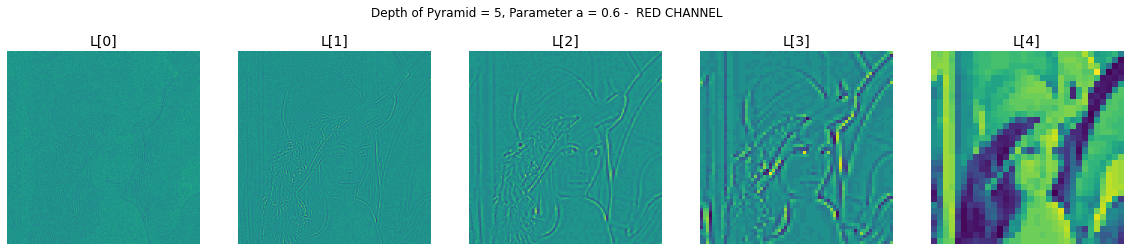

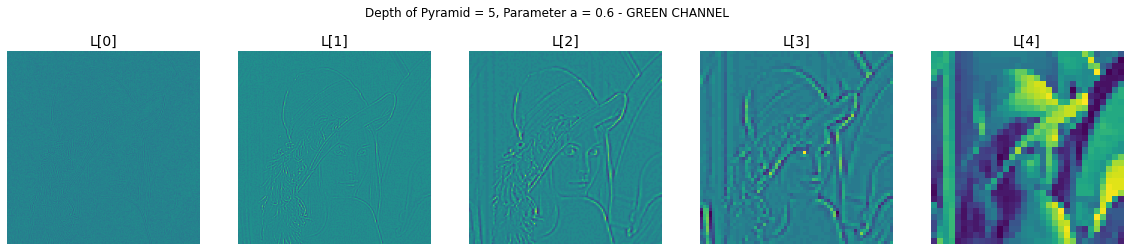

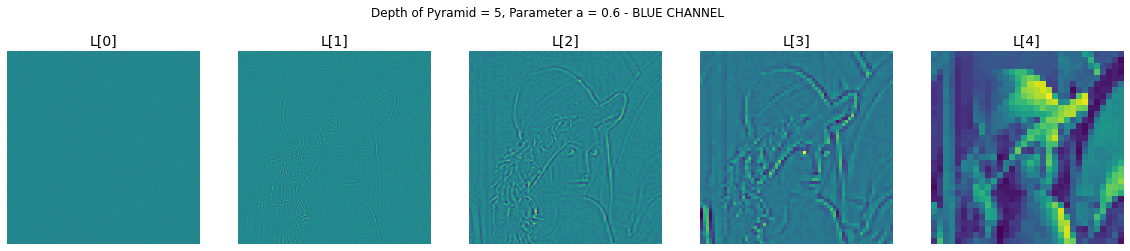

In [ ]:
quant_color_pyr3 = plot_quantized_pyramid(image = lena_color, a = 0.6, depth = 5, bins = bins3)

Image Distorted!
Quantizing with 150 bins:  Entropy =  2.3155 , Variance of Histogram =  0.0067


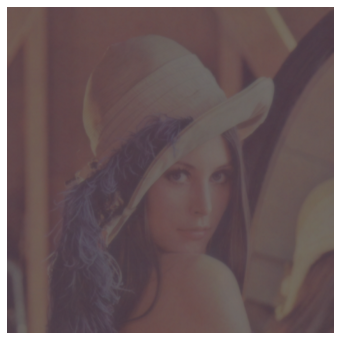

In [ ]:
retrieved_color3 = compare_to_original(lena_color, quant_color_pyr3, a = 0.6)
color_experiments.append(retrieved_color3)

hist = np.zeros([256,1], np.float64)
for pyramid in quant_color_pyr3:
  temp = histogram(pyramid, 5)
  hist = hist + temp
hist = hist / 3
entropy = entropy_calc(hist)
print('Quantizing with 150 bins:',' Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))

### Quantization of Grayscale Cameraman

The same quantization analysis is applied to the grayscale cameraman image, providing a second structural image profile for comparison.

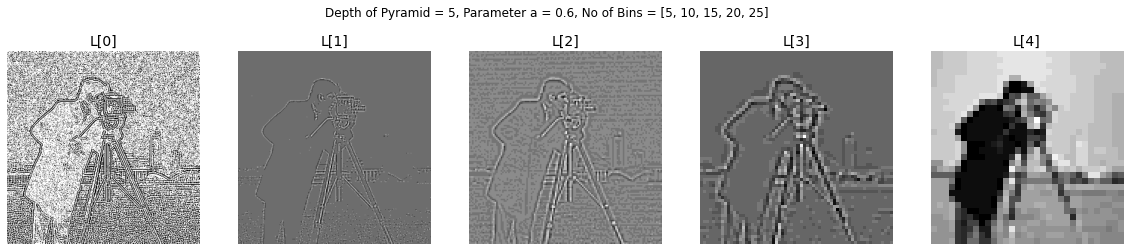

In [ ]:
quant_camera_pyr1 = plot_quantized_pyramid(image = camera, a = 0.6, depth = 5, bins = bins1)
camera_experiments = []

Image Distorted!
Quantizing with 5 bins:  Entropy =  1.9267 , Variance of Histogram =  0.0053


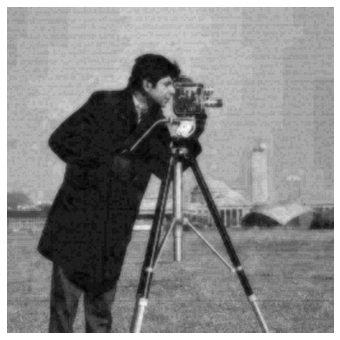

In [ ]:
retrieved_camera1 = compare_to_original(camera, quant_camera_pyr1, a = 0.6)
camera_experiments.append(retrieved_camera1)

hist = histogram(quant_camera_pyr1, 5)
entropy = entropy_calc(hist)
print('Quantizing with 5 bins:',' Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))

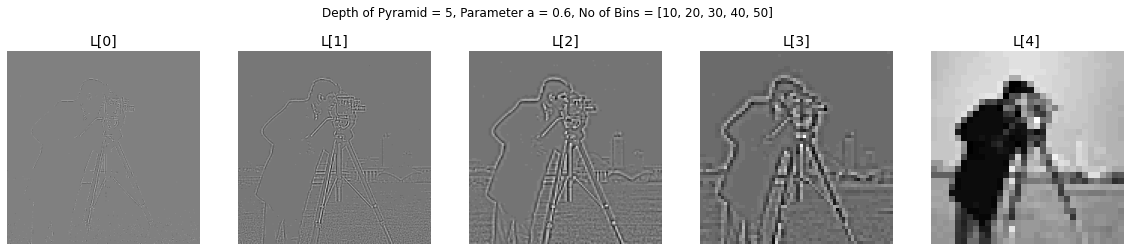

In [ ]:
quant_camera_pyr2 = plot_quantized_pyramid(image = camera, a = 0.6, depth = 5, bins = bins2)

Image Distorted!
Quantizing with 25 bins:  Entropy =  1.4893 , Variance of Histogram =  0.004


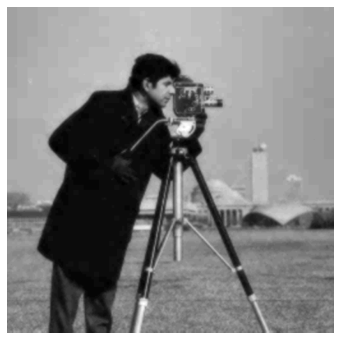

In [ ]:
retrieved_camera2 = compare_to_original(camera, quant_camera_pyr2, a = 0.6)
camera_experiments.append(retrieved_camera2)

hist = histogram(quant_camera_pyr2, 5)
entropy = entropy_calc(hist)
print('Quantizing with 25 bins:',' Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))

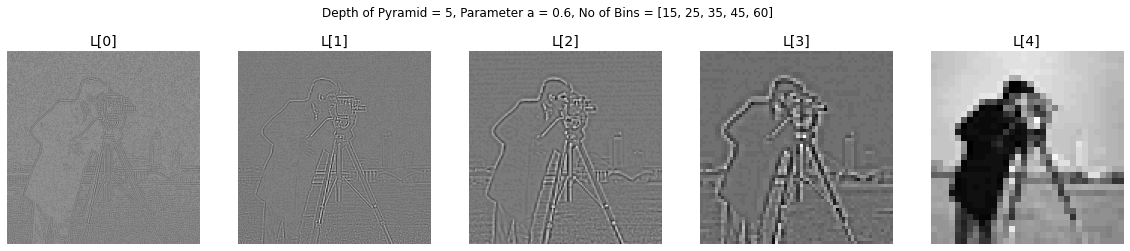

In [ ]:
quant_camera_pyr3 = plot_quantized_pyramid(image = camera, a = 0.6, depth = 5, bins = bins3)

Image Distorted!
Quantizing with 50 bins:  Entropy =  2.2344 , Variance of Histogram =  0.005


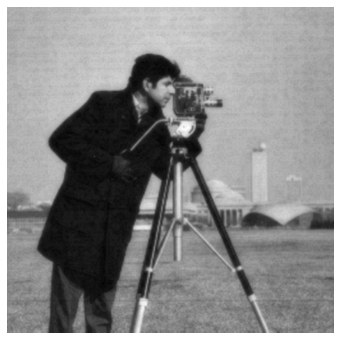

In [ ]:
retrieved_camera3 = compare_to_original(camera, quant_camera_pyr3, a = 0.6)
camera_experiments.append(retrieved_camera3)

hist = histogram(quant_camera_pyr3, 5)
entropy = entropy_calc(hist)
print('Quantizing with 50 bins:',' Entropy = ',np.round(entropy, 4),', Variance of Histogram = ', np.round(np.var(hist), 4))

Reducing the number of quantization bins increases quantization error because a larger range of coefficient values is mapped to the same reconstruction level. At the same time, coarser quantization noticeably reduces entropy and therefore lowers the amount of information required for coding.

The practical objective is therefore not to minimize entropy in isolation, but to select a binning strategy that produces a meaningful entropy reduction while keeping reconstruction artifacts below a visually significant threshold.

## Reconstruction Quality and Signal-to-Noise Analysis

The final quantitative evaluation compares the original images with three reconstructed variants produced by different quantization experiments. Signal-to-noise metrics are used to characterize how much distortion is introduced by the compression-oriented modifications of the Laplacian coefficients.

In [ ]:
def PSNR(original, compressed):
    mse = np.mean((original - compressed) ** 2)
    if(mse == 0):  # MSE is zero means no noise is present in the signal .
                  # Therefore PSNR have no importance.
        return 100
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

def evaluate_experiments(image, experiments):
  for i in range(len(experiments)):
    print('Experiment No ',str(i+1),': PSNR = ', np.round(PSNR(image, experiments[i]), 4),' dB' )

In [ ]:
print('Grayscale Lena Image:\n')
evaluate_experiments(lena_gray, lena_experiments)

Grayscale Lena Image:

Experiment No  1 : PSNR =  27.8661  dB
Experiment No  2 : PSNR =  28.0338  dB
Experiment No  3 : PSNR =  27.735  dB


In [ ]:
print('Coloured Lena Image:\n')
evaluate_experiments(lena_color.astype(np.float64), color_experiments)

Coloured Lena Image:

Experiment No  1 : PSNR =  7.3411  dB
Experiment No  2 : PSNR =  10.5867  dB
Experiment No  3 : PSNR =  12.1772  dB


In [ ]:
print('Grayscale Camera Image:\n')
evaluate_experiments(camera, camera_experiments)

Grayscale Camera Image:

Experiment No  1 : PSNR =  28.5911  dB
Experiment No  2 : PSNR =  27.4046  dB
Experiment No  3 : PSNR =  27.5811  dB


The quantization strategy is consistent with the perceptual interpretation discussed by Burt and Adelson: the bin size at a given Laplacian-pyramid level can be related to the sensitivity of a human observer to errors within a particular spatial-frequency band. Human vision is generally more sensitive to changes in low and medium spatial frequencies than to comparable changes at very high frequencies. This motivates progressively larger quantization bins at coarser or less perceptually critical pyramid components.

Because higher pyramid levels contain fewer samples, their coefficients also contribute less to the total bit rate. The reconstructed images show mild distortion caused by quantization, while the reported PSNR values remain around $30\,\mathrm{dB}$, indicating that the visual degradation remains moderate in the tested configurations. The color image is more sensitive to the quantization process because changes affect both structural content and channel intensity.

Overall, the experiments confirm the central compression trade-off: stronger quantization reduces entropy and therefore the potential coding cost, but this gain is obtained at the expense of reconstruction fidelity.